In [3]:
import os

import galsim
import batsim
import anacal
import numpy as np
import matplotlib.pyplot as plt

from multiprocessing import cpu_count
from parallelbar import progress_starmap
from tqdm import tqdm
from time import time

from importlib import reload
reload(batsim)

<module 'batsim' from '/home/b7009348/FPFS-project/BATSim/src/batsim/__init__.py'>

In [4]:
# Load cosmos catalog
cosmos = galsim.COSMOSCatalog()

# Image pixel scale in arcsec/pixel
scale = 0.2

n_gal = 16
rng = galsim.BaseDeviate(14)
galaxies = cosmos.makeGalaxy(n_random=n_gal, gal_type='parametric', rng=rng)

# Define the PSF
psf = galsim.Moffat(beta=3.5, fwhm=0.7)

# convolve galaxies with PSF
convolved_galaxies = [galsim.Convolve([gal, psf]) for gal in galaxies]
convolved_galaxies = [gal.shift(0.5*scale, 0.5*scale) for gal in convolved_galaxies]

In [5]:
max_diff = 0
for i in range(len(convolved_galaxies)):
    gal_size = galaxies[i].getGoodImageSize(scale)
    conv_size = convolved_galaxies[i].getGoodImageSize(scale)
    diff = abs(conv_size - gal_size)

    if diff > max_diff:
        max_diff = diff

print(f"Maximum size difference between original and convolved galaxies: {max_diff} pixels")

Maximum size difference between original and convolved galaxies: 14 pixels


In [6]:
# Define spacing of galaxies in the grid (in pixels)
grid_spacing = 64
grid_n = np.ceil(np.sqrt(n_gal))

# Create an empty image to hold the scene
galsim_scene = galsim.ImageF(grid_n * grid_spacing, grid_n * grid_spacing, scale=scale)
galsim_scene.setZero()

# Draw each convolved galaxy onto the scene at the appropriate position
for i, obj in tqdm(enumerate(convolved_galaxies)):
    row = i // grid_n # Integer division to get the row index
    col = i % grid_n # Modulo to get the column index

    x = col * grid_spacing + grid_spacing / 2 # Center of the cell in x
    y = row * grid_spacing + grid_spacing / 2 # Center of the cell in y

    obj.drawImage(
        image=galsim_scene,
        center=galsim.PositionD(x, y),
        add_to_image=True,
        method="auto"
    )

16it [00:00, 93.68it/s]


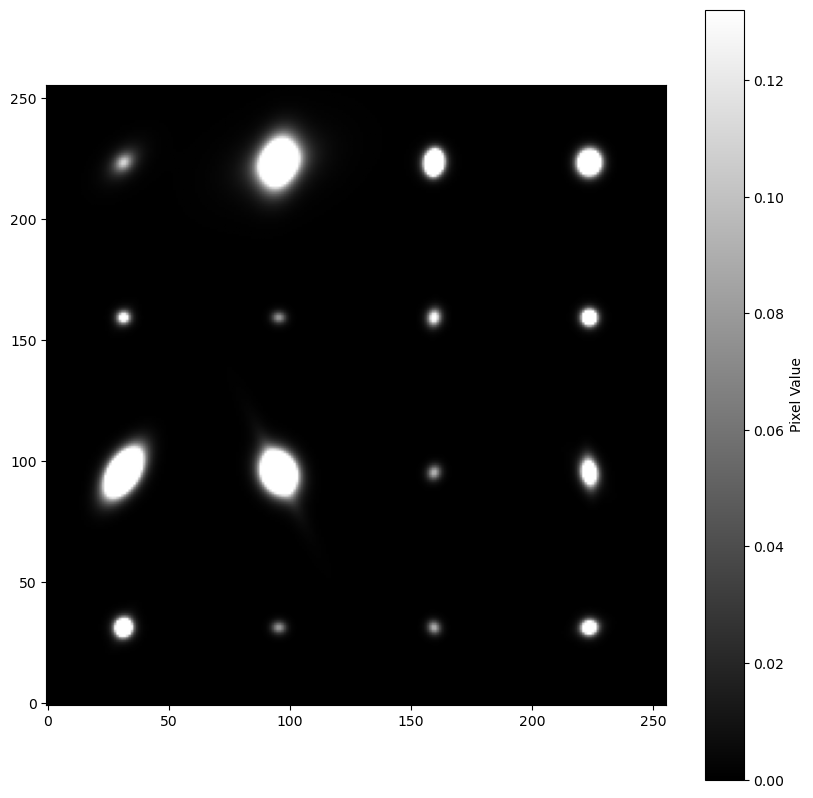

In [7]:
plt.figure(figsize=(10, 10))
plt.imshow(galsim_scene.array, origin='lower', cmap='gray', vmin=0, vmax=np.percentile(galsim_scene.array, 98.5))
plt.colorbar(label='Pixel Value')

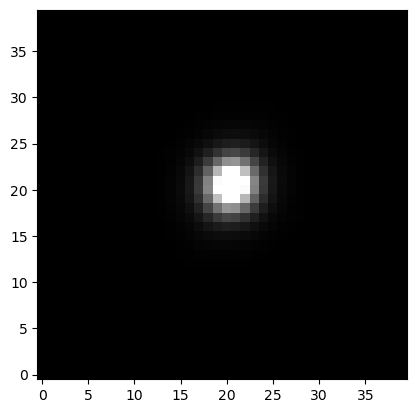

In [8]:
# Repeat process with BATSim
gal_im = batsim.simulate_galaxy(
    gal_obj=galaxies[0],
    ngrid=convolved_galaxies[0].getGoodImageSize(scale),
    psf_obj=psf.shift(0.5*scale, 0.5*scale),
    pix_scale=scale,
    draw_method="auto"
)
plt.imshow(gal_im, origin='lower', cmap='gray', vmin=0, vmax=np.percentile(gal_im, 99.5))

In [37]:
# Define spacing of galaxies in the grid (in pixels)
grid_spacing = 64
grid_n = np.ceil(np.sqrt(n_gal))

# Create an empty image to hold the scene
bat_scene = galsim.ImageF(grid_n * grid_spacing, grid_n * grid_spacing, scale=scale)
bat_scene.setZero()

# Draw each convolved galaxy onto the scene at the appropriate position
for i, obj in tqdm(enumerate(galaxies)):
    row = i // grid_n # Integer division to get the row index
    col = i % grid_n # Modulo to get the column index

    x = col * grid_spacing + grid_spacing / 2 # Center of the cell in x
    y = row * grid_spacing + grid_spacing / 2 # Center of the cell in y

    # Use BATSim to draw the galaxy onto the scene
    gal_im = batsim.simulate_galaxy(
        ngrid=64,
        gal_obj=obj,
        psf_obj=psf.shift(0.5*scale, 0.5*scale),
        pix_scale=scale,
        draw_method="auto",
        maximum_num_grids=4096,
        truncate_ratio=1,
        force_ngrid=False
    )

    # Wrap NumPy array as a GalSim image
    stamp = galsim.ImageF(gal_im, scale=scale)

    # Place the stamp centre at the desired scene location
    stamp.setCenter(int(round(x)), int(round(y)))

    # Add only the overlapping region
    overlap = stamp.bounds & bat_scene.bounds
    if overlap.isDefined():
        bat_scene[overlap] += stamp[overlap]

16it [00:03,  4.96it/s]


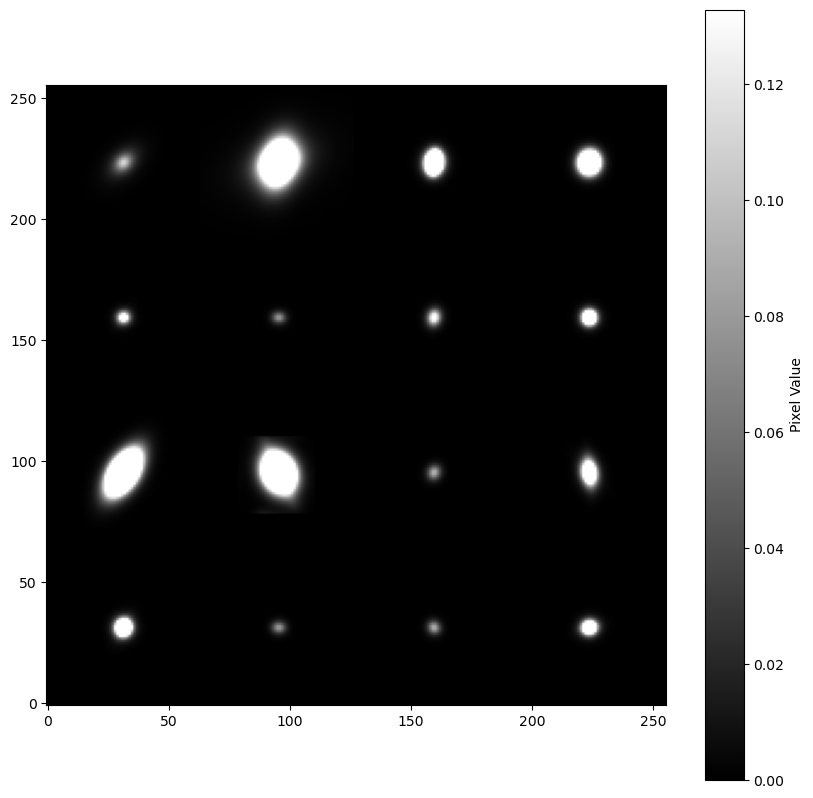

In [38]:
plt.figure(figsize=(10, 10))
plt.imshow(bat_scene.array, origin='lower', cmap='gray', vmin=0, vmax=np.percentile(bat_scene.array, 98.5))
plt.colorbar(label='Pixel Value')

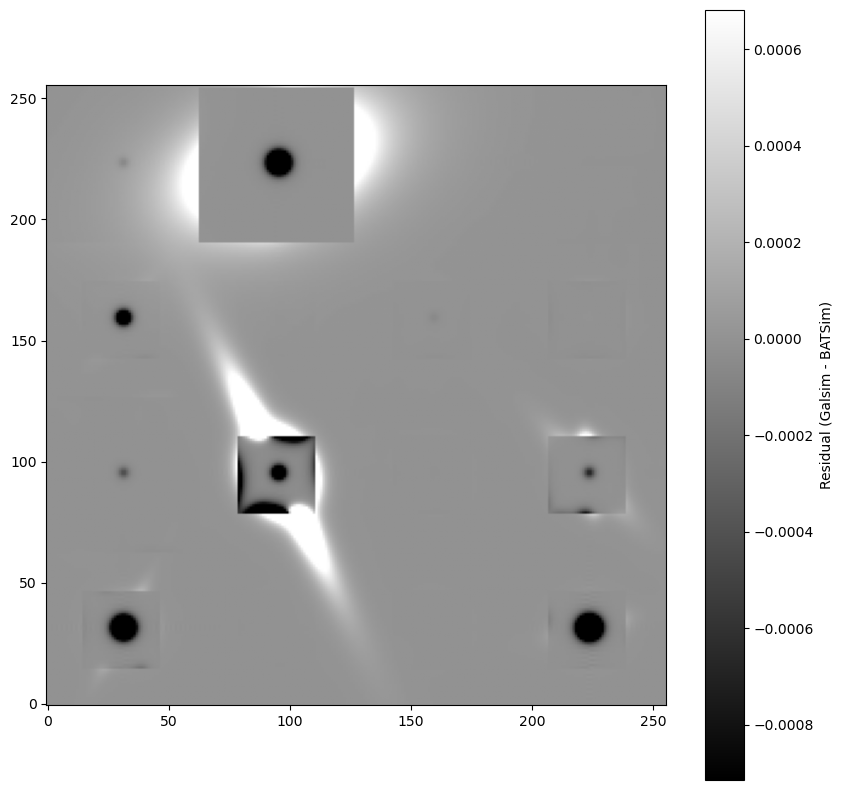

In [39]:
# Show residual between the two scenes
residual = galsim_scene - bat_scene
plt.figure(figsize=(10, 10))
plt.imshow(residual.array, origin='lower', cmap='gray', vmin=-np.percentile(residual.array, 99), vmax=np.percentile(residual.array, 98.5))
plt.colorbar(label='Residual (Galsim - BATSim)')

In [12]:
(0.000075 / 0.02) * 100

0.37499999999999994